In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("C:/Users/LENOVO/Desktop/Placement_project/customer_churn_project/data/processed/customer_churn_clean.csv")

In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7028,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7029,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7030,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [5]:
df.describe()
df.shape

(7032, 21)

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df['Churn'].value_counts(normalize=True)*100 #normalize - converts those counts into proportions.

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [8]:
df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [9]:
churn_rate=(df['Churn']=='Yes').mean()*100
print(f'Customer Churn Rate:{churn_rate:.2f}%')

Customer Churn Rate:26.58%


In [10]:
df[['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']].describe() #here Ml model will affected by outliers&feature distributions- in total charges meanvsmedian

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


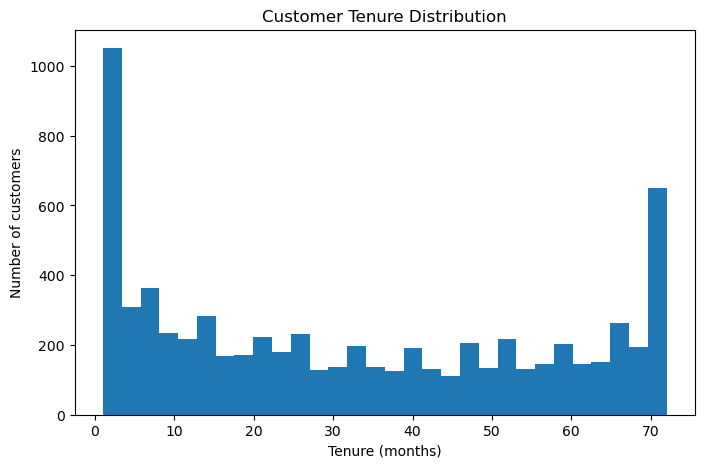

In [11]:
#How long do customers typically stay with the company
plt.figure(figsize=(8,5))
plt.hist(df['tenure'],bins=30)
plt.xlabel('Tenure (months)')
plt.ylabel('Number of customers')
plt.title('Customer Tenure Distribution')
plt.show()

In [12]:
#Do newer customers churn more?
tenure_groups=pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=['0-12','12-24','24-48','48-72']
)
df['Tenure_Groups']=tenure_groups
df['Tenure_Groups']

0        0-12
1       24-48
2        0-12
3       24-48
4        0-12
        ...  
7027    12-24
7028    48-72
7029     0-12
7030     0-12
7031    48-72
Name: Tenure_Groups, Length: 7032, dtype: category
Categories (4, object): ['0-12' < '12-24' < '24-48' < '48-72']

In [13]:
tenure_churn=pd.crosstab(
    df['Tenure_Groups'],
    df['Churn'],
    normalize='index'
)*100
tenure_churn

Churn,No,Yes
Tenure_Groups,,
0-12,52.321839,47.678161
12-24,71.289062,28.710938
24-48,79.611041,20.388959
48-72,90.486824,9.513176


In [14]:
#Are customers paying higher monthly charges more likely to churn?
df.groupby('Churn')['MonthlyCharges'].agg(['mean','median','min','max'])  #You may discover that churned customers have different average charges

,mean,median,min,max
Churn,,,,
No,61.307408,64.45,18.25,118.75
Yes,74.441332,79.65,18.85,118.35


In [15]:
df.groupby("Churn")["tenure"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
Churn,,,,
No,37.650010,38.0,1,72
Yes,17.979133,10.0,1,72


In [16]:
#contract type vs churn
contract_churn=pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
)*100
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [17]:
#payment method vs churn
payment_churn=pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
)*100
payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


In [18]:
security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

security_churn

Churn,No,Yes
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


In [19]:
#internet service vs churn
internet_churn=pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
)*100
internet_churn

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


In [20]:
#Customer Support vs churn- Are customers without technical support more likely to churn?
support_churn=pd.crosstab(
    df['TechSupport'],
    df['Churn'],
    normalize='index'
)*100
support_churn

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


In [21]:
security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

security_churn

Churn,No,Yes
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


In [22]:
#demographic vs churn
demographic_churn=pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100
demographic_churn

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


In [23]:
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

partner_churn

Churn,No,Yes
Partner,,
No,67.023908,32.976092
Yes,80.282935,19.717065


In [24]:
dependent_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

dependent_churn

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.468795,15.531205


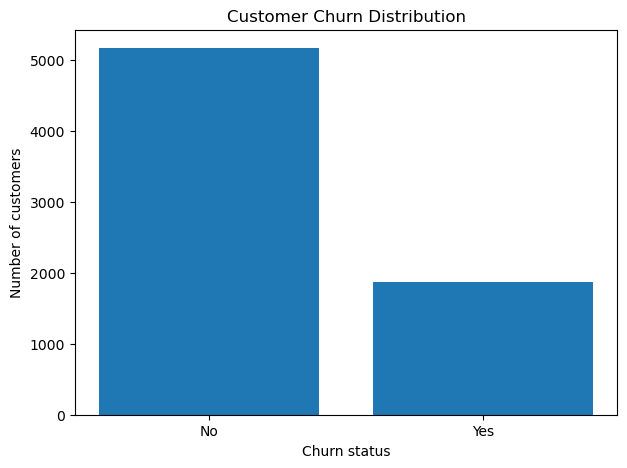

In [25]:
#Visualizations - 1.Business interpretation Approximately 26.6% of customers have churned, meaning roughly 1 in 4 customers in this dataset has left the company.
churn_counts=df['Churn'].value_counts()
plt.figure(figsize=(7,5))
plt.bar(churn_counts.index,churn_counts.values)
plt.title('Customer Churn Distribution')
plt.xlabel('Churn status')
plt.ylabel('Number of customers')
plt.show()

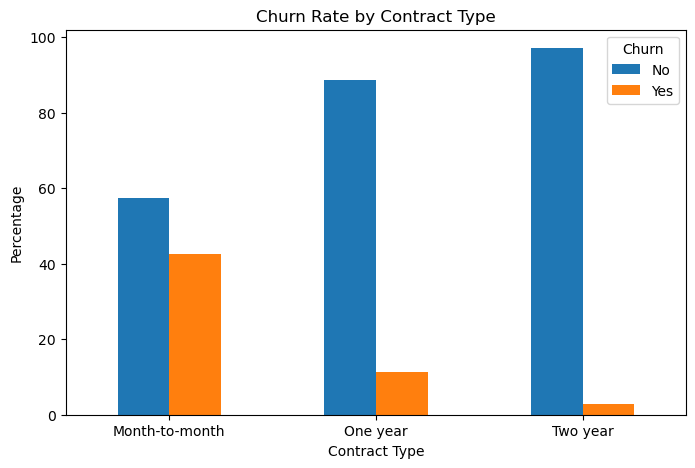

In [26]:
#2. Which contract category has the highest percentage of customers churning?
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")

plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

<Figure size 700x500 with 0 Axes>

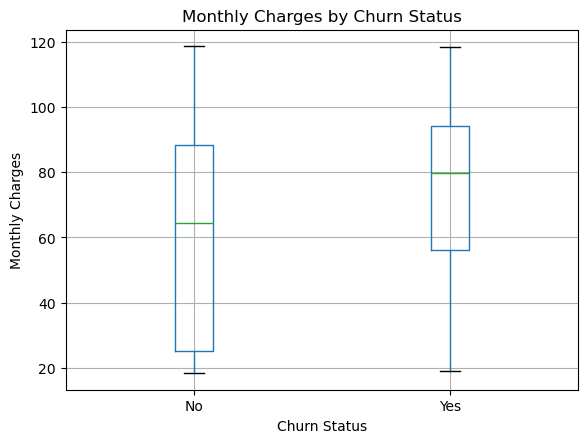

In [27]:
plt.figure(figsize=(7, 5))

df.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.show()

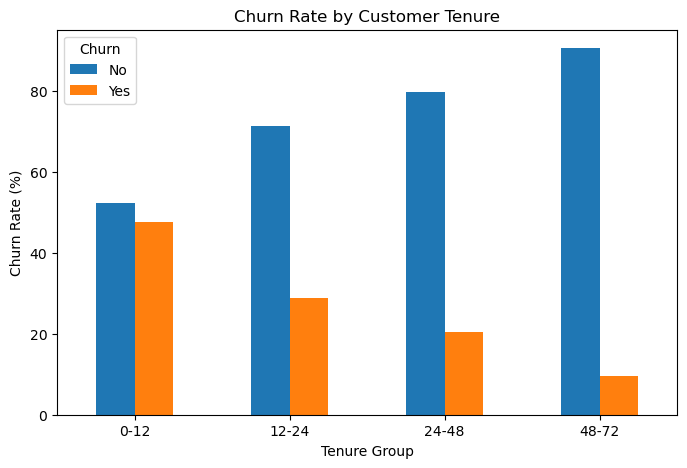

In [28]:
#3. Which stage of the customer lifecycle has the highest churn?
tenure_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

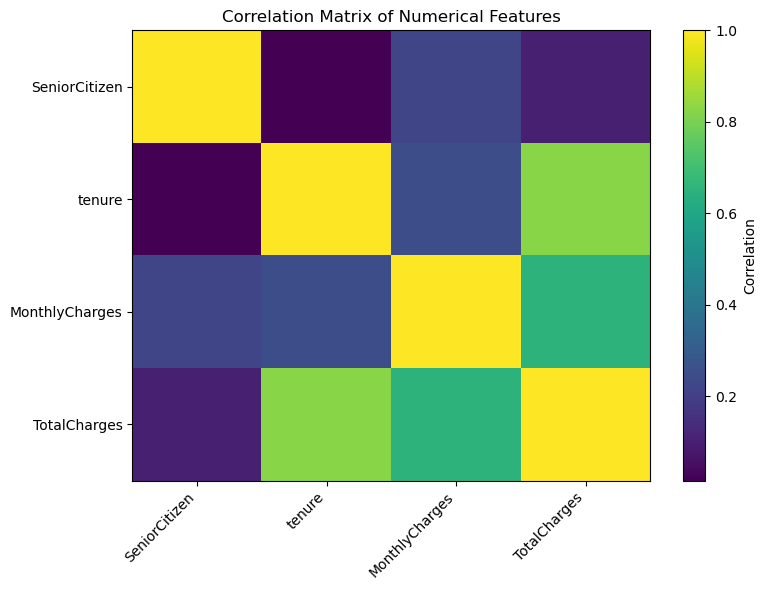

In [29]:
#4. Important Graph - 
numeric_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

corr_matrix = df[numeric_cols].corr()

corr_matrix
plt.figure(figsize=(8, 6))

plt.imshow(corr_matrix, aspect="auto")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.colorbar(label="Correlation")

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()

plt.show()

In [33]:
# Advanced EDA 
#1. It tells us which customer lifecycle + contract combination has higher churn. 
#Which type of contract is most risky at each stage of the customer's lifecycle?
#Which valuable customers are leaving?
tenure_groups=pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=['0-12','12-24','24-48','48-72'],
    include_lowest=True
)

profile=pd.crosstab(
    [df['Contract'], df['Tenure_Groups']],
    df['Churn'],
    normalize='index'
)*100
profile

Churn                                 No        Yes
Contract       Tenure_Groups                       
Month-to-month 0-12            48.645938  51.354062
               12-24           62.279512  37.720488
               24-48           67.082294  32.917706
               48-72           73.976608  26.023392
One year       0-12            89.430894  10.569106
               12-24           91.878173   8.121827
               24-48           89.382239  10.617761
               48-72           87.066246  12.933754
Two year       0-12           100.000000   0.000000
               12-24          100.000000   0.000000
               24-48           97.810219   2.189781
               48-72           96.674584   3.325416

In [34]:
#2. High Churn Probability - We'll define high-value customers using the 75th percentile of monthly charges:
        +
#High Customer Value
        ↓
#HIGH RETENTION PRIORITY

high_value_threshold = df["MonthlyCharges"].quantile(0.75)

high_value_churn = df[
    (df["MonthlyCharges"] >= high_value_threshold) &
    (df["Churn"] == "Yes")
]



In [35]:
high_value_churn.shape

(578, 22)

In [36]:
high_value_churn[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "Churn"
    ]
].head()

,tenure,MonthlyCharges,TotalCharges,Contract,Churn
5,8,99.65,820.50,Month-to-month,Yes
8,28,104.80,3046.05,Month-to-month,Yes
13,49,103.70,5036.30,Month-to-month,Yes
26,47,99.35,4749.15,Month-to-month,Yes
38,34,106.35,3549.25,Month-to-month,Yes


In [37]:
#3. This gives the business a financial perspective.
revenue_at_risk = df.loc[
    df["Churn"] == "Yes",
    "MonthlyCharges"
].sum()

print(f"Historical monthly revenue associated with churned customers: ${revenue_at_risk:,.2f}")

Historical monthly revenue associated with churned customers: $139,130.85


In [38]:
#4.High-Risk Customer Profile : 
high_risk = df[
    (df["Contract"] == "Month-to-month") &
    (df["tenure"] <= 12) &
    (df["MonthlyCharges"] >= df["MonthlyCharges"].quantile(0.75))
]


In [39]:
high_risk_churn_rate = (
    high_risk["Churn"] == "Yes"
).mean() * 100

print(f"High-risk segment churn rate: {high_risk_churn_rate:.2f}%")

High-risk segment churn rate: 77.10%


In [40]:
print("Customers in segment:", len(high_risk))

Customers in segment: 214
